In [1]:
from pathlib import Path
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder, find_peaks
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Paths
cutout_dir = Path("../data/raw/v854_cen_dasch/cutouts")
output_dir = Path("../outputs/tables")
os.makedirs(output_dir, exist_ok=True)

# Detection parameters
FWHM = 3.0
THRESHOLD_SIGMA = 5.0
MIN_SOURCES_DAO = 5   # fall back to find_peaks if DAOStarFinder finds fewer than this
BOX_SIZE = 11         # for find_peaks

cutouts = sorted(cutout_dir.glob("*.fits"))
print(f"Found {len(cutouts)} cutouts to process")

Found 31 cutouts to process


In [2]:
def detect_sources(fits_path):
    """
    Run source detection on a single cutout FITS file.
    Returns (sources, algorithm_used, data, data_sub, std)
    """
    # Load data
    data = fits.getdata(fits_path).astype(float)
    data = np.nan_to_num(data, nan=np.nanmedian(data))

    # Background stats
    mean, median, std = sigma_clipped_stats(data, sigma=3.0)
    data_sub = data - median

    # Try DAOStarFinder first 
    try:
        daofind = DAOStarFinder(
            fwhm=FWHM,
            threshold=THRESHOLD_SIGMA * std,
            sharpness_range=(0.2, 2.0)
        )
        dao_sources = daofind(data_sub)
        n_dao = 0 if dao_sources is None else len(dao_sources)
    except Exception:
        dao_sources = None
        n_dao = 0

    if n_dao >= MIN_SOURCES_DAO:
        # DAOStarFinder worked and used
        sources = dao_sources
        algorithm = "DAOStarFinder"
        x_col, y_col = "x_centroid", "y_centroid"
    else:
        # Fall back to find_peaks
        sources = find_peaks(data_sub, threshold=THRESHOLD_SIGMA * std, box_size=BOX_SIZE)
        algorithm = "find_peaks"
        x_col, y_col = "x_peak", "y_peak"

    return sources, algorithm, data, data_sub, std, x_col, y_col

00000_b03435m0s0.fits                     algorithm=find_peaks       sources=43
00002_b03520m0s0.fits                     algorithm=find_peaks       sources=6


00003_b03521m0s0.fits                     algorithm=find_peaks       sources=8
00004_b03623m0s0.fits                     algorithm=find_peaks       sources=62


00022_b05223m0s0.fits                     algorithm=find_peaks       sources=121
00023_b05252m0s0.fits                     algorithm=find_peaks       sources=0


00025_b05310m0s0.fits                     algorithm=find_peaks       sources=0
00026_b05327m0s0.fits                     algorithm=DAOStarFinder    sources=34
00028_b05479m0s0.fits                     algorithm=DAOStarFinder    sources=19
00029_b05480m0s0.fits                     algorithm=DAOStarFinder    sources=197
00030_b05485m0s0.fits                     algorithm=DAOStarFinder    sources=109
00041_b05982m0s0.fits                     algorithm=DAOStarFinder    sources=68
00042_b05983m0s0.fits                     algorithm=DAOStarFinder    sources=58
00043_b06065m0s0.fits                     algorithm=find_peaks       sources=8
00044_b06068m0s0.fits                     algorithm=find_peaks       sources=5


00052_b07646m3s0.fits                     algorithm=find_peaks       sources=9
00053_b07647m0s0.fits                     algorithm=find_peaks       sources=16


00071_b09146m0s0.fits                     algorithm=DAOStarFinder    sources=42
00073_b09411m0s0.fits                     algorithm=find_peaks       sources=65


00075_b09473m0s0.fits                     algorithm=DAOStarFinder    sources=7
00077_b09708m0s0.fits                     algorithm=DAOStarFinder    sources=9
00083_b11025m0s0.fits                     algorithm=DAOStarFinder    sources=8
00085_b11204m0s0.fits                     algorithm=find_peaks       sources=31


00086_b11273m0s0.fits                     algorithm=DAOStarFinder    sources=24
00088_b11353m0s0.fits                     algorithm=DAOStarFinder    sources=136
00089_b11354m0s0.fits                     algorithm=DAOStarFinder    sources=19
00090_b11355m0s0.fits                     algorithm=DAOStarFinder    sources=37
00091_b11356m0s0.fits                     algorithm=DAOStarFinder    sources=15
00092_b11357m0s0.fits                     algorithm=DAOStarFinder    sources=11
00093_b11358m0s0.fits                     algorithm=DAOStarFinder    sources=23
00095_b11431m0s0.fits                     algorithm=DAOStarFinder    sources=7

Done!
algorithm
DAOStarFinder    18
find_peaks       13
Name: count, dtype: int64


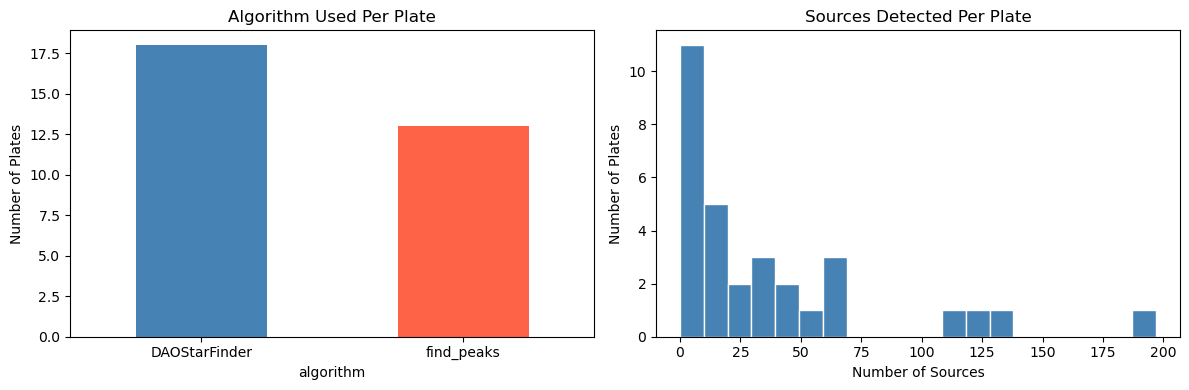

In [5]:
results_summary = []

for fits_path in cutouts:
    try:
        sources, algorithm, data, data_sub, std, x_col, y_col = detect_sources(fits_path)
        n_sources = 0 if sources is None else len(sources)

        print(f"{fits_path.name:40s}  algorithm={algorithm:15s}  sources={n_sources}")

        results_summary.append({
            "plate": fits_path.name,
            "algorithm": algorithm,
            "n_sources": n_sources
        })

        # Save per-plate source table
        if sources is not None and n_sources > 0:
            out_path = output_dir / (fits_path.stem + "_sources.ecsv")
            sources.write(out_path, overwrite=True)

    except Exception as e:
        print(f"{fits_path.name:40s}  ERROR: {e}")
        results_summary.append({
            "plate": fits_path.name,
            "algorithm": "error",
            "n_sources": 0
        })

# Save summary
summary_df = pd.DataFrame(results_summary)
summary_df.to_csv(output_dir / "detection_summary.csv", index=False)
print("\nDone!")
print(summary_df["algorithm"].value_counts())

summary_df = pd.read_csv(output_dir / "detection_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Algorithm breakdown
summary_df["algorithm"].value_counts().plot.bar(ax=axes[0], color=["steelblue", "tomato", "gray"])
axes[0].set_title("Algorithm Used Per Plate")
axes[0].set_ylabel("Number of Plates")
axes[0].tick_params(axis="x", rotation=0)

# Sources detected per plate
axes[1].hist(summary_df["n_sources"], bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Sources Detected Per Plate")
axes[1].set_xlabel("Number of Sources")
axes[1].set_ylabel("Number of Plates")

plt.tight_layout()
plt.show()

In [3]:
import ipywidgets as widgets
from IPython.display import display

dropdown = widgets.Dropdown(
    options=[(f.name, f) for f in cutouts],
    description="Plate:"
)

output = widgets.Output()

def show_plate(change):
    with output:
        from IPython.display import clear_output
        clear_output(wait=True)

        fits_path = change["new"]
        sources, algorithm, data, data_sub, std, x_col, y_col = detect_sources(fits_path)
        n_sources = 0 if sources is None else len(sources)

        print(f"Algorithm: {algorithm}")
        print(f"Sources detected: {n_sources}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Raw plate
        axes[0].imshow(data, origin="lower", cmap="gray")
        axes[0].set_title(f"{fits_path.name}\n(raw)")

        # Detected sources
        axes[1].imshow(data, origin="lower", cmap="gray")
        if sources is not None and n_sources > 0:
            axes[1].scatter(
                sources[x_col], sources[y_col],
                s=120, facecolors="none", edgecolors="red"
            )
        axes[1].set_title(f"Detected Sources ({algorithm})")

        plt.tight_layout()
        plt.show()

dropdown.observe(show_plate, names="value")
display(dropdown, output)

Dropdown(description='Plate:', options=(('00000_b03435m0s0.fits', WindowsPath('../data/raw/v854_cen_dasch/cuto…

Output()